<a href="https://colab.research.google.com/github/Nihilyteo/Integrador-EthnicEcuadorian-Clasificador/blob/main/Integrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador - Visión por Computador
## Meta 1: Selección y Análisis del Dataset

**Dataset:** [Dataset of Ethnic facial images of Ecuadorian people](https://figshare.com/articles/dataset/Dataset_of_Ethnic_facial_images_of_Ecuadorian_people/8266730)

**Clases:** European descendants, Afro-ecuadorians, Indigenous, Mestizos

Este notebook cubre:
1. Importación de librerías
2. Carga del dataset (Google Drive / local)
3. Análisis básico: número de instancias total y por clase, número de clases, resolución promedio, formatos
4. Visualización de la distribución de clases y muestras de imágenes
5. **Balanceo del dataset** (undersampling de la clase mayoritaria a 50 instancias por clase)

## 1. Librerías

**Librerías base** (manejo de archivos, imágenes y datos):

| Librería | Uso en este proyecto |
|---|---|
| `os`, `glob`, `pathlib.Path` | Recorrer carpetas del dataset, buscar rutas de imágenes y manejar nombres de archivo |
| `cv2` (OpenCV) | Leer imágenes; preprocesamiento (CLAHE, Otsu, filtro bilateral); extracción de características (SIFT, ORB) |
| `mahotas` | Cálculo de los Momentos de Zernike (no están disponibles en OpenCV) |
| `numpy` | Cálculos numéricos y manejo de vectores/arreglos de características |
| `pandas` | Organizar resultados en tablas (DataFrames) y exportar/leer CSV |
| `matplotlib`, `seaborn` | Graficar distribuciones, comparaciones antes/después, dendrogramas, etc. |
| `PIL` (Pillow) | Verificación adicional de formato/metadatos de imagen |

**Librerías agregadas en fases posteriores**, agrupadas por propósito general (no se detalla una por una,
porque varias cumplen el mismo rol dentro de una misma fase):

- **Particiones y escalado de datos (`scikit-learn`)**: `train_test_split`, `StratifiedKFold`,
  `StandardScaler`, `LabelEncoder` — dividir el dataset en train/test de forma estratificada y normalizar
  las características antes de entrenar cualquier modelo.
- **Clasificación clásica (`scikit-learn`)**: `SVC` (SVM) y `RandomForestClassifier`, junto con sus métricas
  de evaluación (`accuracy_score`, `classification_report`).
- **Clustering (`scikit-learn` + `scipy`)**: `AgglomerativeClustering` y `PCA` (reducción de dimensionalidad
  antes de agrupar); `scipy.cluster.hierarchy` para el dendrograma; `scipy.spatial.distance` para calcular
  el índice de Dunn (no incluido en scikit-learn, se implementa manualmente).
- **Deep Learning (`tensorflow`/`keras`)**: construcción y entrenamiento de la CNN directamente sobre las
  imágenes originales.
- **Entorno Colab (`google.colab`, `concurrent.futures`)**: montar Google Drive y paralelizar el
  preprocesamiento/extracción de características con múltiples hilos.

In [1]:
# --- Manejo de archivos, rutas y datos ---
import os
import glob
import time
from pathlib import Path
import numpy as np
import pandas as pd

# --- Imágenes y procesamiento ---
import cv2
from PIL import Image

# --- Extracción de características avanzada (Momentos de Zernike) ---
!pip install mahotas -q
import mahotas

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning clásico (particiones, escalado, clasificación) ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              silhouette_score, adjusted_rand_score,
                              adjusted_mutual_info_score)

# --- Clustering (jerárquico + reducción de dimensionalidad + índice de Dunn) ---
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# --- Persistencia de modelos (para la web app obligatoria) ---
import joblib

# --- Deep Learning (CNN) ---
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Entorno Colab y paralelización ---
from google.colab import drive
from concurrent.futures import ThreadPoolExecutor

# Configuración de estilo para las gráficas
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías cargadas correctamente.')
print('OpenCV version:', cv2.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 33.6 MB/s eta 0:00:00
Librerías cargadas correctamente.
OpenCV version: 4.13.0


## 2. Configuración del Entorno y Carga de Datos

Para garantizar la reproducibilidad del experimento, se establece la conexión con el sistema de almacenamiento en la nube (Google Drive) y se definen las rutas absolutas del directorio de trabajo. Se verifica la integridad de la ruta para asegurar que los procesos posteriores interactúen exclusivamente con el conjunto de datos definido para este proyecto.

In [4]:
# Montar Google Drive
drive.mount('/content/drive')

# Definir la ruta específica del proyecto (basado en la estructura de la imagen)
DATASET_PATH = '/content/drive/MyDrive/Intregrador/8266730'
OUTPUT_PATH = '/content/drive/MyDrive/Intregrador/outputs'

# Verificar que la ruta del dataset exista antes de continuar
if os.path.exists(DATASET_PATH):
    print(f"✓ Ruta del dataset verificada correctamente: {DATASET_PATH}")
    os.makedirs(OUTPUT_PATH, exist_ok=True)
    print(f"✓ Directorio de salida configurado en: {OUTPUT_PATH}")
else:
    print(f"⚠ ERROR: No se encontró la ruta {DATASET_PATH}. Verifica el nombre de las carpetas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Ruta del dataset verificada correctamente: /content/drive/MyDrive/Intregrador/8266730
✓ Directorio de salida configurado en: /content/drive/MyDrive/Intregrador/outputs


## 3. Análisis Exploratorio del Dataset (EDA)

Antes de proceder con el preprocesamiento y la extracción de características, se realiza un análisis descriptivo del conjunto de imágenes. Este proceso identifica métricas fundamentales como el volumen total de instancias, la distribución de clases, la resolución espacial promedio y los formatos de archivo presentes.

Esta etapa es crítica para detectar anomalías, como el desbalanceo de clases, que puedan comprometer el entrenamiento de los modelos de Machine Learning. **El balanceo propiamente dicho se aplica en el siguiente paso (3.1)**, una vez identificado el desbalance.

--- REPORTE DE ANÁLISIS BÁSICO (ANTES DEL BALANCEO) ---
Total de instancias procesadas: 430
Número total de clases: 4

Distribución de instancias por clase:
               clase  num_instancias
            Mestizos             280
    Afro-ecuadorians              50
European descendants              50
          Indigenous              50

Resolución promedio: 1280 x 1920 px
Resolución mínima detectada: 1280 x 1862 px
Resolución máxima detectada: 1280 x 1920 px

Formatos de archivo encontrados: ['jpg']

[!] ADVERTENCIA CRÍTICA: Dataset altamente desbalanceado (Ratio clase mayor/menor = 5.6x).
    -> Se aplicará balanceo por undersampling en el siguiente paso (Meta 3.1).


/tmp/ipykernel_1328/1161042847.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_clases, x='clase', y='num_instancias', palette='viridis')


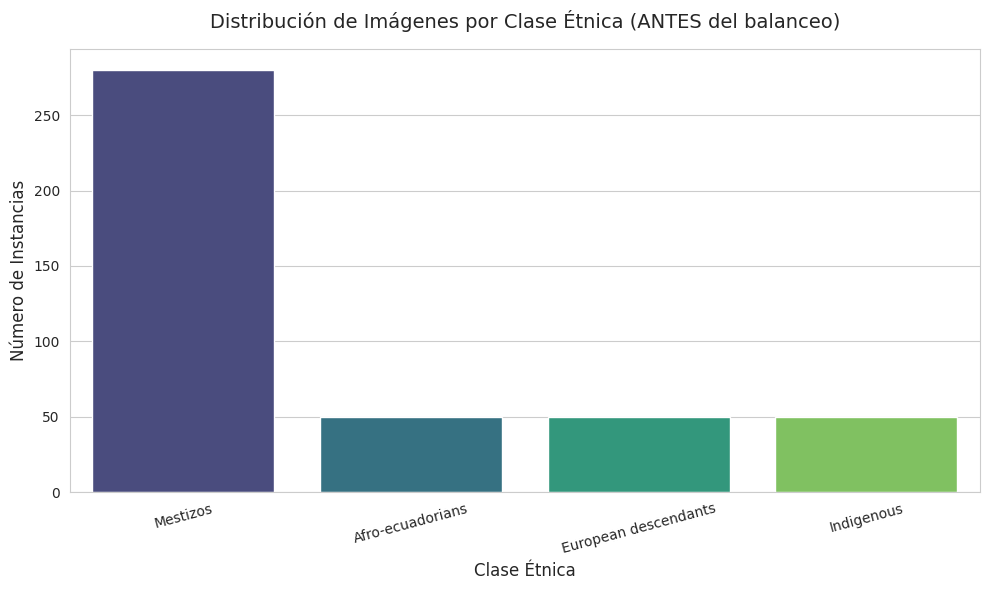

In [5]:
def analisis_basico(dataset_path):
    """
    Recorre las subcarpetas (clases) de dataset_path y calcula métricas descriptivas.
    Excluye directorios no correspondientes a clases (ej. 'metadata').
    """
    excluir = {'metadata'}
    extensiones = ['jpg']

    clases = sorted([d for d in os.listdir(dataset_path)
                      if os.path.isdir(os.path.join(dataset_path, d))
                      and d.lower() not in excluir])

    filas = []
    for clase in clases:
        clase_path = os.path.join(dataset_path, clase)
        imagenes = []
        for ext in extensiones:
            imagenes.extend(glob.glob(os.path.join(clase_path, '**', f'*.{ext}'), recursive=True))
            imagenes.extend(glob.glob(os.path.join(clase_path, '**', f'*.{ext.upper()}'), recursive=True))

        for img_path in imagenes:
            formato = Path(img_path).suffix.lower().replace('.', '')
            img = cv2.imread(img_path)
            if img is not None:
                alto, ancho = img.shape[:2]
            else:
                alto, ancho = None, None

            filas.append({
                'ruta': img_path,
                'clase': clase,
                'alto': alto,
                'ancho': ancho,
                'formato': formato
            })

    detalle_imagenes = pd.DataFrame(filas)

    resumen_clases = (detalle_imagenes
                       .groupby('clase')
                       .size()
                       .reset_index(name='num_instancias')
                       .sort_values('num_instancias', ascending=False))

    print('--- REPORTE DE ANÁLISIS BÁSICO (ANTES DEL BALANCEO) ---')
    print(f'Total de instancias procesadas: {len(detalle_imagenes)}')
    print(f'Número total de clases: {len(clases)}\n')

    print('Distribución de instancias por clase:')
    print(resumen_clases.to_string(index=False))

    if detalle_imagenes['alto'].notna().any():
        print(f'\nResolución promedio: {detalle_imagenes["alto"].mean():.0f} x {detalle_imagenes["ancho"].mean():.0f} px')
        print(f'Resolución mínima detectada: {detalle_imagenes["alto"].min():.0f} x {detalle_imagenes["ancho"].min():.0f} px')
        print(f'Resolución máxima detectada: {detalle_imagenes["alto"].max():.0f} x {detalle_imagenes["ancho"].max():.0f} px')

    print(f'\nFormatos de archivo encontrados: {sorted(detalle_imagenes["formato"].unique())}')

    ratio = resumen_clases['num_instancias'].max() / resumen_clases['num_instancias'].min()
    if ratio > 1.5:
        print(f'\n[!] ADVERTENCIA CRÍTICA: Dataset altamente desbalanceado (Ratio clase mayor/menor = {ratio:.1f}x).')
        print('    -> Se aplicará balanceo por undersampling en el siguiente paso (Meta 3.1).')

    plt.figure(figsize=(10, 6))
    sns.barplot(data=resumen_clases, x='clase', y='num_instancias', palette='viridis')
    plt.title('Distribución de Imágenes por Clase Étnica (ANTES del balanceo)', fontsize=14, pad=15)
    plt.xlabel('Clase Étnica', fontsize=12)
    plt.ylabel('Número de Instancias', fontsize=12)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'distribucion_original.png'), dpi=150)
    plt.show()

    return resumen_clases, detalle_imagenes

resumen_clases, detalle_imagenes = analisis_basico(DATASET_PATH)

## 3.1 Balanceo del Dataset (Undersampling de la clase mayoritaria)

El análisis exploratorio anterior confirmó un fuerte desbalance: **Mestizos (280 instancias)** frente a solo
**50 instancias** en cada una de las otras tres etnias (Afroecuatoriano, Europeo-descendiente, Indígena), es
decir, una razón de 5.6 a 1.

Para corregir este desbalance se aplica una técnica de **submuestreo aleatorio (random undersampling)** sobre
la clase mayoritaria: de las 280 imágenes de "Mestizos" se seleccionan aleatoriamente solo 50 (semilla fija
`random_state=42`, para que el resultado sea reproducible), quedando el dataset balanceado en **50 imágenes
por clase (200 en total)**.

**¿Por qué reducir (undersampling) en vez de aumentar (oversampling/SMOTE)?**
- Reducir la clase mayoritaria a 50 evita introducir imágenes sintéticas o duplicadas, preservando
  únicamente datos reales y evitando el riesgo de sobreajuste a copias/variaciones artificiales de los
  mismos rostros.
- Con las 4 clases en igualdad de instancias, ningún algoritmo (clasificador o de clustering) tiene un sesgo
  estructural hacia la clase con más ejemplos: cada etnia pesa exactamente lo mismo en el entrenamiento y en
  la evaluación (accuracy, F1, Silhouette, Dunn, ARI, AMI dejan de estar distorsionados por el desbalance).
- La desventaja es una reducción del volumen total de datos (de 430 a 200 imágenes), lo que puede aumentar
  la varianza de las métricas y limitar el aprendizaje de modelos con más parámetros (como la CNN). Esta
  limitación se documenta en las conclusiones finales.

Todas las fases posteriores (preprocesamiento, extracción de características, clasificación, clustering y
CNN) se ejecutan **exclusivamente sobre este subconjunto balanceado de 200 imágenes**.

Aplicando balanceo del dataset (undersampling a 50 imágenes por clase)...

--- RESUMEN DEL BALANCEO ---
               clase  instancias_originales  instancias_balanceadas
    Afro-ecuadorians                     50                      50
European descendants                     50                      50
          Indigenous                     50                      50
            Mestizos                    280                      50

Total de imágenes tras el balanceo: 200 (antes: 430)


/tmp/ipykernel_1328/2138785072.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_balanceo, x='clase', y='instancias_balanceadas', palette='crest')


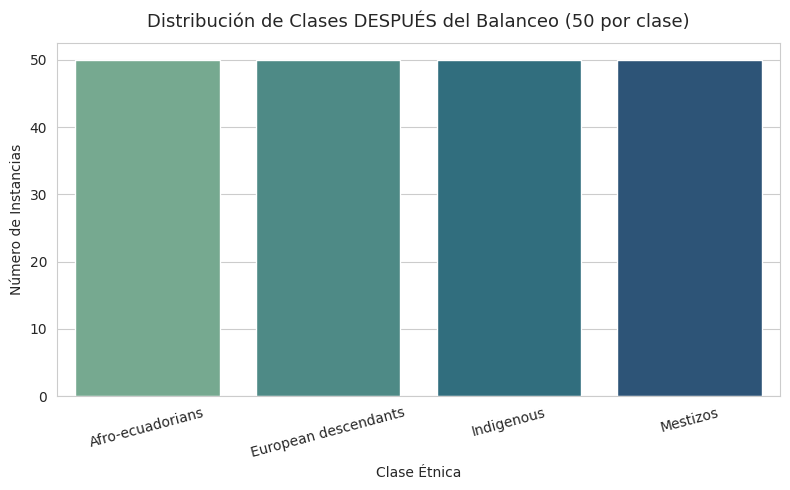

In [6]:
print("Aplicando balanceo del dataset (undersampling a 50 imágenes por clase)...")

N_INSTANCIAS_OBJETIVO = 50
SEMILLA_BALANCEO = 42

rng_balanceo = np.random.RandomState(SEMILLA_BALANCEO)

rutas_balanceadas = {}
filas_balanceo = []

for clase in sorted(detalle_imagenes['clase'].unique()):
    rutas_clase = detalle_imagenes.loc[detalle_imagenes['clase'] == clase, 'ruta'].tolist()
    n_disponibles = len(rutas_clase)

    if n_disponibles > N_INSTANCIAS_OBJETIVO:
        rutas_seleccionadas = list(rng_balanceo.choice(rutas_clase, N_INSTANCIAS_OBJETIVO, replace=False))
    else:
        rutas_seleccionadas = rutas_clase

    rutas_balanceadas[clase] = rutas_seleccionadas
    filas_balanceo.append({
        'clase': clase,
        'instancias_originales': n_disponibles,
        'instancias_balanceadas': len(rutas_seleccionadas)
    })

df_balanceo = pd.DataFrame(filas_balanceo)
print("\n--- RESUMEN DEL BALANCEO ---")
print(df_balanceo.to_string(index=False))

total_balanceado = sum(len(v) for v in rutas_balanceadas.values())
print(f"\nTotal de imágenes tras el balanceo: {total_balanceado} (antes: {len(detalle_imagenes)})")

NOMBRES_BALANCEADOS = {clase: set(Path(r).name for r in rutas) for clase, rutas in rutas_balanceadas.items()}

df_balanceo.to_csv(os.path.join(OUTPUT_PATH, 'resumen_balanceo_dataset.csv'), index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_balanceo, x='clase', y='instancias_balanceadas', palette='crest')
plt.title('Distribución de Clases DESPUÉS del Balanceo (50 por clase)', fontsize=13, pad=12)
plt.xlabel('Clase Étnica'); plt.ylabel('Número de Instancias')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'distribucion_balanceada.png'), dpi=150)
plt.show()

## 4. Preprocesamiento de Imágenes

Para garantizar la homogeneidad de los datos y optimizar la extracción de características, las imágenes del **subconjunto balanceado** (200 imágenes, 50 por clase) son sometidas a un pipeline de preprocesamiento. Se aplican las siguientes técnicas:

1. **Reducción de dimensionalidad:** Escalado a 256x256 píxeles para disminuir el costo computacional.
2. **Filtro Bilateral:** Reducción de ruido de alta frecuencia preservando la nitidez de los bordes estructurales del rostro.
3. **CLAHE (Contrast Limited Adaptive Histogram Equalization):** Mejora adaptativa del contraste para mitigar variaciones drásticas de iluminación.
4. **Umbralización de Otsu:** Binarización automática para separar las estructuras principales del fondo.

Para optimizar el rendimiento y evitar cuellos de botella por iteración secuencial (bucles `for`), la ejecución se paraleliza utilizando `ThreadPoolExecutor`.

**IMPORTANTE - Corrección técnica:** La imagen que se guarda tras el pipeline (CLAHE + Otsu) queda binarizada
(blanco y negro puro). Para los **Momentos de Zernike** esto está bien (funcionan sobre forma/silueta), pero
**SIFT y ORB** pierden la mayor parte de su información de gradiente/textura si se calculan sobre una imagen
binaria. Por eso en el bloque de extracción de características se calculan SIFT y ORB sobre la versión con
CLAHE (antes de aplicar Otsu), y se reserva la versión binarizada solo para Momentos de Zernike.

Iniciando preprocesamiento en paralelo de 200 imágenes (subconjunto balanceado)...
✓ Preprocesamiento completado.
  - Imágenes procesadas exitosamente: 200/200
  - Tiempo de ejecución: 23.66 segundos.
  - Destino: /content/drive/MyDrive/Intregrador/outputs/preprocesadas
Generando comparacion visual antes/despues del preprocesamiento...


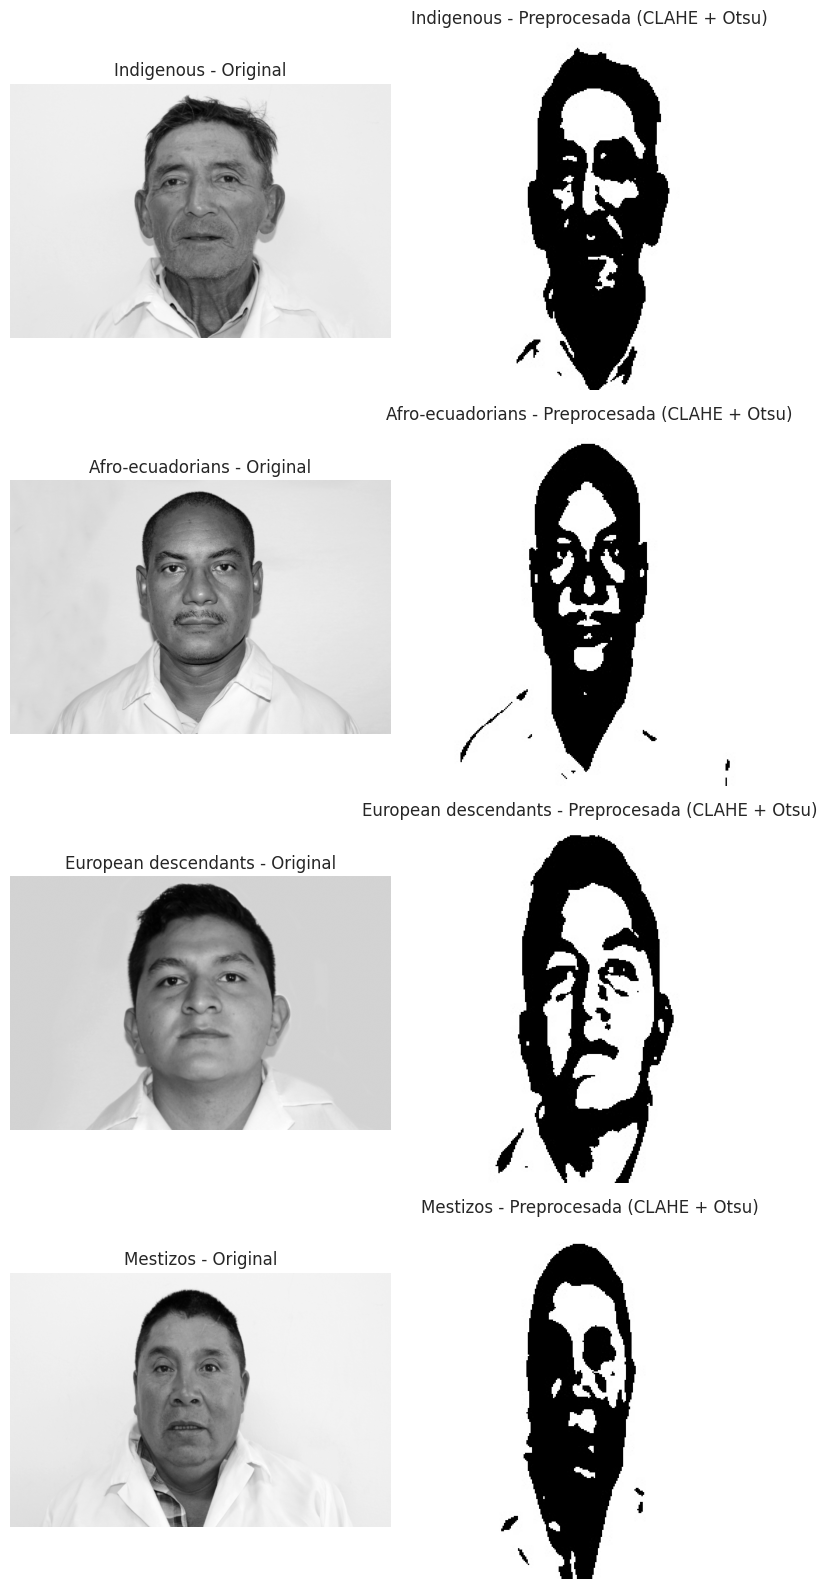

Comparacion guardada en: /content/drive/MyDrive/Intregrador/outputs/comparacion_antes_despues.png


In [7]:
# Definir las rutas donde se guardarán las imágenes procesadas
PREPROCESSED_PATH = os.path.join(OUTPUT_PATH, 'preprocesadas')
PREPROCESSED_CLAHE_PATH = os.path.join(OUTPUT_PATH, 'preprocesadas_clahe')
os.makedirs(PREPROCESSED_PATH, exist_ok=True)
os.makedirs(PREPROCESSED_CLAHE_PATH, exist_ok=True)

DIMENSION_OBJETIVO = (256, 256)

def preprocesar_y_guardar(argumentos):
    """
    Función vectorizada y optimizada para procesar una sola imagen.
    Guarda DOS versiones: la binarizada (Otsu) y la de contraste mejorado (CLAHE, sin binarizar).
    """
    ruta_img, ruta_salida_bin, ruta_salida_clahe = argumentos

    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False

    img_resized = cv2.resize(img, DIMENSION_OBJETIVO, interpolation=cv2.INTER_AREA)
    img_blur = cv2.bilateralFilter(img_resized, d=5, sigmaColor=50, sigmaSpace=50)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img_blur)

    _, img_umbral = cv2.threshold(img_clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    cv2.imwrite(ruta_salida_bin, img_umbral)
    cv2.imwrite(ruta_salida_clahe, img_clahe)
    return True

tareas = []
clases = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d)) and d.lower() != 'metadata']

for clase in clases:
    ruta_clase_origen = os.path.join(DATASET_PATH, clase)
    ruta_clase_destino_bin = os.path.join(PREPROCESSED_PATH, clase)
    ruta_clase_destino_clahe = os.path.join(PREPROCESSED_CLAHE_PATH, clase)
    os.makedirs(ruta_clase_destino_bin, exist_ok=True)
    os.makedirs(ruta_clase_destino_clahe, exist_ok=True)

    imagenes = glob.glob(os.path.join(ruta_clase_origen, '**', '*.[jJ][pP][gG]'), recursive=True)

    # Filtrar SOLO las imágenes que quedaron seleccionadas tras el balanceo (Meta 3.1)
    nombres_permitidos = NOMBRES_BALANCEADOS.get(clase, set())
    imagenes = [p for p in imagenes if Path(p).name in nombres_permitidos]

    for img_path in imagenes:
        nombre_archivo = Path(img_path).name
        ruta_salida_bin = os.path.join(ruta_clase_destino_bin, nombre_archivo)
        ruta_salida_clahe = os.path.join(ruta_clase_destino_clahe, nombre_archivo)
        tareas.append((img_path, ruta_salida_bin, ruta_salida_clahe))

print(f"Iniciando preprocesamiento en paralelo de {len(tareas)} imágenes (subconjunto balanceado)...")
inicio = time.time()

exitosos = 0
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    resultados = executor.map(preprocesar_y_guardar, tareas)
    exitosos = sum(1 for res in resultados if res)

tiempo_total = time.time() - inicio
print(f"✓ Preprocesamiento completado.")
print(f"  - Imágenes procesadas exitosamente: {exitosos}/{len(tareas)}")
print(f"  - Tiempo de ejecución: {tiempo_total:.2f} segundos.")
print(f"  - Destino: {PREPROCESSED_PATH}")

print("Generando comparacion visual antes/despues del preprocesamiento...")

muestras_clases = clases[:4] if len(clases) >= 4 else clases
fig, axes = plt.subplots(len(muestras_clases), 2, figsize=(8, 4 * len(muestras_clases)))
if len(muestras_clases) == 1:
    axes = axes.reshape(1, 2)

for idx, clase in enumerate(muestras_clases):
    ruta_clase_prep = os.path.join(PREPROCESSED_PATH, clase)
    imgs_prep = glob.glob(os.path.join(ruta_clase_prep, '*.[jJ][pP][gG]'))
    if not imgs_prep:
        continue
    img_original = cv2.imread(imgs_prep[0].replace(PREPROCESSED_PATH, DATASET_PATH), cv2.IMREAD_GRAYSCALE)
    img_procesada = cv2.imread(imgs_prep[0], cv2.IMREAD_GRAYSCALE)

    if img_original is not None:
        axes[idx, 0].imshow(img_original, cmap='gray')
    axes[idx, 0].set_title(f'{clase} - Original')
    axes[idx, 0].axis('off')

    if img_procesada is not None:
        axes[idx, 1].imshow(img_procesada, cmap='gray')
    axes[idx, 1].set_title(f'{clase} - Preprocesada (CLAHE + Otsu)')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'comparacion_antes_despues.png'), dpi=150)
plt.show()
print(f"Comparacion guardada en: {os.path.join(OUTPUT_PATH, 'comparacion_antes_despues.png')}")

## 5. Extracción de Características (Feature Extraction)

En esta fase, las imágenes preprocesadas (subconjunto balanceado, 200 imágenes) se transforman en vectores
numéricos estructurados. Se aplican tres técnicas de extracción, cada una de naturaleza distinta:

1. **Momentos de Zernike (Forma/Geometría, sobre la versión binarizada - Otsu):** descriptores basados en
   polinomios ortogonales de Zernike, invariantes a rotación, que capturan la forma global de la silueta
   facial con mayor riqueza que los Momentos de Hu (se usa grado=8, generando 25 valores).
2. **SIFT - Scale-Invariant Feature Transform (Puntos clave/avanzada, sobre la versión CLAHE):** detecta
   puntos clave invariantes a escala y rotación, describiendo cada uno con un vector de 128 valores. Se fija
   un máximo de 32 puntos clave por imagen (igual que ORB) para obtener un vector de tamaño constante
   (32 x 128 = 4096 características), permitiendo su almacenamiento tabular.
3. **ORB - Oriented FAST and Rotated BRIEF (Puntos clave/rápida, sobre la versión CLAHE):** extractor local
   eficiente y binario. Se fija igualmente un máximo de 32 puntos clave (1024 características).

El proceso se paraleliza para optimizar los tiempos de cómputo, generando tres conjuntos de datos (CSVs)
independientes, listos para la fase de modelado predictivo.

In [8]:
print("Iniciando extracción de características en paralelo...")

NUM_PUNTOS_ORB = 32
LONGITUD_DESCRIPTOR_ORB = NUM_PUNTOS_ORB * 32

NUM_PUNTOS_SIFT = 32
LONGITUD_DESCRIPTOR_SIFT = NUM_PUNTOS_SIFT * 128

RADIO_ZERNIKE = 128
GRADO_ZERNIKE = 8

def extraer_features_imagen(ruta_img_bin):
    """
    Extrae Momentos de Zernike (sobre la version binarizada/Otsu) y
    SIFT + ORB (sobre la version CLAHE, sin binarizar, para conservar gradientes/textura).
    """
    clase = Path(ruta_img_bin).parent.name
    nombre_archivo = Path(ruta_img_bin).name
    ruta_img_clahe = os.path.join(PREPROCESSED_CLAHE_PATH, clase, nombre_archivo)

    img_bin = cv2.imread(ruta_img_bin, cv2.IMREAD_GRAYSCALE)
    img_clahe = cv2.imread(ruta_img_clahe, cv2.IMREAD_GRAYSCALE)
    if img_bin is None or img_clahe is None:
        return None

    t0 = time.time()
    zernike = mahotas.features.zernike_moments(img_bin, radius=RADIO_ZERNIKE, degree=GRADO_ZERNIKE)
    t_zernike = time.time() - t0

    t0 = time.time()
    sift = cv2.SIFT_create(nfeatures=NUM_PUNTOS_SIFT)
    kp_sift, des_sift = sift.detectAndCompute(img_clahe, None)
    if des_sift is None:
        sift_feat = np.zeros(LONGITUD_DESCRIPTOR_SIFT)
    else:
        flat_des = des_sift.flatten()
        if len(flat_des) < LONGITUD_DESCRIPTOR_SIFT:
            sift_feat = np.pad(flat_des, (0, LONGITUD_DESCRIPTOR_SIFT - len(flat_des)), 'constant')
        else:
            sift_feat = flat_des[:LONGITUD_DESCRIPTOR_SIFT]
    t_sift = time.time() - t0

    t0 = time.time()
    orb = cv2.ORB_create(nfeatures=NUM_PUNTOS_ORB)
    kp_orb, des_orb = orb.detectAndCompute(img_clahe, None)
    if des_orb is None:
        orb_feat = np.zeros(LONGITUD_DESCRIPTOR_ORB)
    else:
        flat_des = des_orb.flatten()
        if len(flat_des) < LONGITUD_DESCRIPTOR_ORB:
            orb_feat = np.pad(flat_des, (0, LONGITUD_DESCRIPTOR_ORB - len(flat_des)), 'constant')
        else:
            orb_feat = flat_des[:LONGITUD_DESCRIPTOR_ORB]
    t_orb = time.time() - t0

    return (zernike, sift_feat, orb_feat, clase, t_zernike, t_sift, t_orb)

rutas_imagenes = glob.glob(os.path.join(PREPROCESSED_PATH, '**', '*.*'), recursive=True)
rutas_validas = [r for r in rutas_imagenes if r.lower().endswith(('.jpg', '.jpeg', '.png'))]

inicio_extraccion = time.time()

datos_zernike, datos_sift, datos_orb = [], [], []
tiempos_zernike, tiempos_sift, tiempos_orb = [], [], []

with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    resultados = executor.map(extraer_features_imagen, rutas_validas)

    for res in resultados:
        if res is not None:
            zernike, sift_f, orb_f, clase, t_z, t_s, t_o = res
            datos_zernike.append(np.append(zernike, clase))
            datos_sift.append(np.append(sift_f, clase))
            datos_orb.append(np.append(orb_f, clase))
            tiempos_zernike.append(t_z)
            tiempos_sift.append(t_s)
            tiempos_orb.append(t_o)

tiempo_total_ext = time.time() - inicio_extraccion
print(f"✓ Extracción completada en {tiempo_total_ext:.2f} segundos.")

def guardar_dataset(datos, nombre_archivo, prefijo):
    df = pd.DataFrame(datos)
    num_features = df.shape[1] - 1
    df.columns = [f"{prefijo}_{i}" for i in range(num_features)] + ['class']
    ruta_csv = os.path.join(OUTPUT_PATH, nombre_archivo)
    df.to_csv(ruta_csv, index=False)
    print(f"  -> {nombre_archivo} guardado | Dimensiones: {df.shape}")

print("\nGuardando datasets...")
guardar_dataset(datos_zernike, "dataset_zernike_moments.csv", "zernike")
guardar_dataset(datos_sift, "dataset_sift.csv", "sift")
guardar_dataset(datos_orb, "dataset_orb.csv", "orb")

comparacion_tecnicas = pd.DataFrame({
    'Técnica': ['Momentos de Zernike', 'SIFT', 'ORB'],
    'N° características': [len(datos_zernike[0]) - 1, len(datos_sift[0]) - 1, len(datos_orb[0]) - 1],
    'Formato de salida': ['Vector de 25 momentos (grado 8)', 'Vector concatenado (32 keypoints x 128)', 'Vector binario concatenado (32 keypoints x 32 bytes)'],
    'Tiempo promedio/img (s)': [np.mean(tiempos_zernike), np.mean(tiempos_sift), np.mean(tiempos_orb)],
    'Tiempo total (s)': [np.sum(tiempos_zernike), np.sum(tiempos_sift), np.sum(tiempos_orb)],
    'Representación': ['Global (forma/silueta)', 'Local (puntos clave + descriptores de gradiente)', 'Local (puntos clave + descriptores binarios)']
})

print("\n--- TABLA COMPARATIVA DE TÉCNICAS DE EXTRACCIÓN (para el informe conjunto) ---")
print(comparacion_tecnicas.to_string(index=False))

comparacion_tecnicas.to_csv(os.path.join(OUTPUT_PATH, 'comparacion_tecnicas_extraccion.csv'), index=False)
print(f"\nGuardado en: {os.path.join(OUTPUT_PATH, 'comparacion_tecnicas_extraccion.csv')}")

print("\n¡Proceso de Visión por Computador finalizado con éxito! Archivos listos para Machine Learning.")

Iniciando extracción de características en paralelo...
✓ Extracción completada en 24.26 segundos.

Guardando datasets...
  -> dataset_zernike_moments.csv guardado | Dimensiones: (200, 26)
  -> dataset_sift.csv guardado | Dimensiones: (200, 4097)
  -> dataset_orb.csv guardado | Dimensiones: (200, 1025)

--- TABLA COMPARATIVA DE TÉCNICAS DE EXTRACCIÓN (para el informe conjunto) ---
            Técnica  N° características                                    Formato de salida  Tiempo promedio/img (s)  Tiempo total (s)                                   Representación
Momentos de Zernike                  25                      Vector de 25 momentos (grado 8)                 0.177565         35.512904                           Global (forma/silueta)
               SIFT                4096              Vector concatenado (32 keypoints x 128)                 0.033943          6.788640 Local (puntos clave + descriptores de gradiente)
                ORB                1024 Vector binario concate

## 6. Clasificación con CNN (directamente sobre las imágenes originales)

A diferencia de los clasificadores clásicos (que usan los descriptores manuales extraídos en el paso
anterior), la CNN se entrena **directamente sobre las imágenes originales**, sin CLAHE ni umbralización de
por medio, para evaluar si una red convolucional puede aprender representaciones útiles por sí sola, sin
necesidad de ingeniería de características manual. Se usa el mismo subconjunto balanceado de 200 imágenes
(50 por clase) que el resto del proyecto, y el mismo split 70/30 estratificado para que la comparación con
los modelos clásicos sea justa.

Con un conjunto de entrenamiento tan reducido (~140 imágenes), la red no logra aprender si solo ve cada
imagen una vez por época: se queda estancada desde el inicio. Para darle más pasos de entrenamiento por
época sin alterar el balance entre clases, cada imagen se repite 4 veces (combinado con aumento de datos
distinto en cada pasada), lo que hace el entrenamiento algo más lento pero permite que el modelo
efectivamente aprenda en lugar de quedar atascado en una predicción constante.

Iniciando clasificación con CNN (imágenes originales, sin preprocesar)...
Imagenes originales cargadas: 200 | forma: (128, 128, 3)
Clases: [np.str_('Afro-ecuadorians'), np.str_('European descendants'), np.str_('Indigenous'), np.str_('Mestizos')]
Imagenes de entrenamiento tras repetir x4: 560


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aumento_datos (Sequential)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.2353 - loss: 1.4035 - val_accuracy: 0.2024 - val_loss: 1.3950 - learning_rate: 5.0000e-04
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2563 - loss: 1.3858 - val_accuracy: 0.2024 - val_loss: 1.3882 - learning_rate: 5.0000e-04
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.2752 - loss: 1.3827 - val_accuracy: 0.2024 - val_loss: 1.3901 - learning_rate: 5.0000e-04
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2479 - loss: 1.3866 - val_accuracy: 0.2024 - val_loss: 1.3872 - learning_rate: 5.0000e-04
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3004 - loss: 1.3834 - val_accuracy: 0.2024 - val_loss: 1.3887 - learning_rate: 5.0000e-04
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2479 - loss: 1.3878 - val_accuracy: 0.2024 - val_loss: 1.3862 - learning_rate: 5.0000e-04
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2542 - loss:

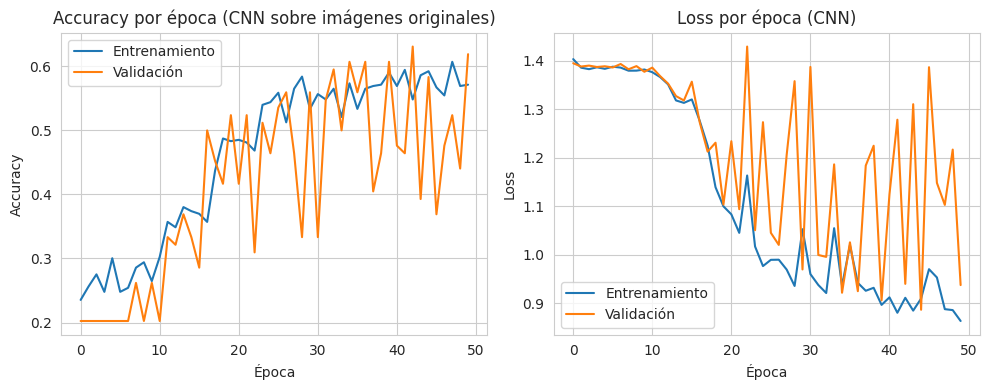

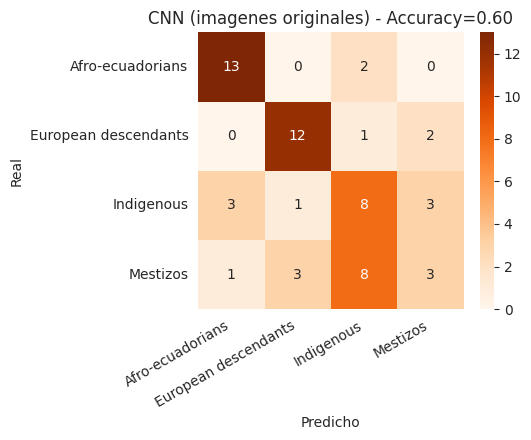


--- COMPARACIÓN DE COSTO COMPUTACIONAL ---
CNN: 1158.61 s de entrenamiento sobre imagenes ORIGINALES sin preprocesar (110.1 MB en memoria)
Clasificadores clásicos: entrenan en fracciones de segundo sobre vectores de características ya extraídos (Zernike/SIFT/ORB)
-> La CNN requiere mucho mas tiempo/computo, pero se salta por completo el preprocesamiento y la extraccion manual de caracteristicas.


In [9]:
print("Iniciando clasificación con CNN (imágenes originales, sin preprocesar)...")

IMG_SIZE = (128, 128)

X_img, y_clase = [], []
for clase, rutas in rutas_balanceadas.items():
    for ruta in rutas:
        img = cv2.imread(ruta, cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        X_img.append(img)
        y_clase.append(clase)

X_img = np.array(X_img, dtype='float32') / 255.0
print(f"Imagenes originales cargadas: {X_img.shape[0]} | forma: {X_img.shape[1:]}")

le = LabelEncoder()
y_encoded = le.fit_transform(y_clase)
num_clases = len(le.classes_)
print(f"Clases: {list(le.classes_)}")

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_img, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

# Con un dataset tan chico (~140 imagenes de entrenamiento tras el balanceo y el split),
# la red se queda estancada desde la primera epoca si solo ve cada imagen una vez por
# epoca (muy pocos pasos de gradiente). Se repite cada imagen 4 veces (con aumento de
# datos distinto en cada pasada) para darle a la red mas pasos de entrenamiento por
# epoca sin romper el balance entre clases (todas se repiten por igual).
FACTOR_REPETICION = 4
rng_cnn = np.random.RandomState(42)
idx_repetido = np.tile(np.arange(len(X_train_cnn)), FACTOR_REPETICION)
rng_cnn.shuffle(idx_repetido)
X_train_cnn, y_train_cnn = X_train_cnn[idx_repetido], y_train_cnn[idx_repetido]
print(f"Imagenes de entrenamiento tras repetir x{FACTOR_REPETICION}: {X_train_cnn.shape[0]}")

aumento_datos = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name='aumento_datos')

modelo_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    aumento_datos,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_clases, activation='softmax')
])

modelo_cnn.compile(optimizer=tf.keras.optimizers.Adam(5e-4, clipnorm=1.0),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelo_cnn.summary()

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

inicio_cnn = time.time()
historial = modelo_cnn.fit(
    X_train_cnn, y_train_cnn,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
tiempo_cnn = time.time() - inicio_cnn

y_pred_cnn = np.argmax(modelo_cnn.predict(X_test_cnn), axis=1)
acc_cnn = accuracy_score(y_test_cnn, y_pred_cnn)

print(f"\n✓ CNN finalizada en {tiempo_cnn:.2f} s | Accuracy: {acc_cnn:.4f}")

# Guardar el modelo y el label encoder para la web app (Meta 9, obligatoria)
MODELS_PATH = os.path.join(OUTPUT_PATH, 'modelos_webapp')
os.makedirs(MODELS_PATH, exist_ok=True)
modelo_cnn.save(os.path.join(MODELS_PATH, 'cnn_modelo.keras'))
joblib.dump(le, os.path.join(MODELS_PATH, 'cnn_label_encoder.joblib'))
print(f"Modelo CNN guardado en: {MODELS_PATH}/cnn_modelo.keras")
print("\nReporte de Clasificación (CNN):")
print(classification_report(y_test_cnn, y_pred_cnn, target_names=le.classes_, zero_division=0))

resultados_cnn = {
    'Accuracy': acc_cnn,
    'Tiempo': tiempo_cnn,
    'Reporte': classification_report(y_test_cnn, y_pred_cnn, target_names=le.classes_, output_dict=True, zero_division=0)
}

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(historial.history['accuracy'], label='Entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época (CNN sobre imágenes originales)')
plt.xlabel('Época'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial.history['loss'], label='Entrenamiento')
plt.plot(historial.history['val_loss'], label='Validación')
plt.title('Loss por época (CNN)')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'cnn_curvas_entrenamiento.png'), dpi=150)
plt.show()

# Matriz de confusion de la CNN (para el informe y la web app)
from sklearn.metrics import confusion_matrix

cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'CNN (imagenes originales) - Accuracy={acc_cnn:.2f}')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'cnn_matriz_confusion.png'), dpi=150)
plt.show()

print("\n--- COMPARACIÓN DE COSTO COMPUTACIONAL ---")
print(f"CNN: {tiempo_cnn:.2f} s de entrenamiento sobre imagenes ORIGINALES sin preprocesar ({X_train_cnn.nbytes/1e6:.1f} MB en memoria)")
print("Clasificadores clásicos: entrenan en fracciones de segundo sobre vectores de características ya extraídos (Zernike/SIFT/ORB)")
print("-> La CNN requiere mucho mas tiempo/computo, pero se salta por completo el preprocesamiento y la extraccion manual de caracteristicas.")

## 7. Machine Learning: Clasificadores Clásicos (SVM y Random Forest)

En esta fase tomamos los tres conjuntos de características extraídas (Zernike, SIFT y ORB) para entrenar modelos de aprendizaje supervisado. Por cada conjunto de datos se entrenarán dos clasificadores:
1. **Support Vector Machine (SVM):** Excelente para encontrar hiperplanos de separación en espacios de alta dimensionalidad (como SIFT).
2. **Random Forest:** Algoritmo de ensamble robusto que maneja bien las interacciones no lineales.

**Estrategia contra el desbalanceo:** Aunque el dataset ya fue balanceado por undersampling (Meta 3.1, 50 imágenes por clase), se mantiene `stratify` durante la división de datos (Train 70% / Test 30%) y `class_weight='balanced'` en los clasificadores como buena práctica general, para reforzar la robustez del entrenamiento. Los datos numéricos son estandarizados (`StandardScaler`) previamente, paso crítico para que SVM converja rápida y correctamente.

In [10]:
# Cross-Validation (Stratified K-Fold, k=5) sobre los 3 datasets de caracteristicas
print("Ejecutando Cross-Validation (Stratified K-Fold, k=5)...")

archivos_csv_cv = {
    'Momentos de Zernike': 'dataset_zernike_moments.csv',
    'SIFT': 'dataset_sift.csv',
    'ORB': 'dataset_orb.csv'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {}

for nombre_desc, archivo in archivos_csv_cv.items():
    ruta_csv = os.path.join(OUTPUT_PATH, archivo)
    if not os.path.exists(ruta_csv):
        print(f"Error: No se encontró {archivo}")
        continue

    df = pd.read_csv(ruta_csv)
    X = df.drop('class', axis=1)
    y = df['class']

    scaler_cv = StandardScaler()
    X_scaled = scaler_cv.fit_transform(X)

    modelos_cv = {
        'SVM': SVC(kernel='linear', class_weight='balanced', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
    }

    resultados_cv[nombre_desc] = {}
    print(f"\n--- {nombre_desc} ---")
    for nombre_modelo, modelo in modelos_cv.items():
        scores = cross_val_score(modelo, X_scaled, y, cv=skf, scoring='accuracy', n_jobs=-1)
        resultados_cv[nombre_desc][nombre_modelo] = {'media': scores.mean(), 'std': scores.std()}
        print(f"  {nombre_modelo}: Accuracy CV = {scores.mean():.4f} (+/- {scores.std():.4f})")

filas_cv = []
for descriptor, modelos in resultados_cv.items():
    for modelo, valores in modelos.items():
        filas_cv.append({'Descriptor': descriptor, 'Clasificador': modelo,
                          'Accuracy CV (media)': valores['media'], 'Accuracy CV (std)': valores['std']})

df_cv = pd.DataFrame(filas_cv)
print("\n--- TABLA RESUMEN CROSS-VALIDATION ---")
print(df_cv.to_string(index=False))
df_cv.to_csv(os.path.join(OUTPUT_PATH, 'resultados_cross_validation.csv'), index=False)

Ejecutando Cross-Validation (Stratified K-Fold, k=5)...

--- Momentos de Zernike ---
  SVM: Accuracy CV = 0.3550 (+/- 0.0510)
  Random Forest: Accuracy CV = 0.3700 (+/- 0.0696)

--- SIFT ---
  SVM: Accuracy CV = 0.3850 (+/- 0.0436)
  Random Forest: Accuracy CV = 0.2650 (+/- 0.0406)

--- ORB ---
  SVM: Accuracy CV = 0.3950 (+/- 0.0579)
  Random Forest: Accuracy CV = 0.3900 (+/- 0.0784)

--- TABLA RESUMEN CROSS-VALIDATION ---
         Descriptor  Clasificador  Accuracy CV (media)  Accuracy CV (std)
Momentos de Zernike           SVM                0.355           0.050990
Momentos de Zernike Random Forest                0.370           0.069642
               SIFT           SVM                0.385           0.043589
               SIFT Random Forest                0.265           0.040620
                ORB           SVM                0.395           0.057879
                ORB Random Forest                0.390           0.078422


In [11]:
print("Iniciando entrenamiento de modelos de Machine Learning...")

# Carpeta donde se guardaran los modelos entrenados, para que la web app
# obligatoria (ver seccion 9) pueda cargarlos despues
MODELS_PATH = os.path.join(OUTPUT_PATH, 'modelos_webapp')
os.makedirs(MODELS_PATH, exist_ok=True)

SLUG_DESCRIPTOR = {'Momentos de Zernike': 'zernike', 'SIFT': 'sift', 'ORB': 'orb'}

archivos_csv = {
    'Momentos de Zernike': 'dataset_zernike_moments.csv',
    'SIFT': 'dataset_sift.csv',
    'ORB': 'dataset_orb.csv'
}

resultados_ml = {}

for nombre_desc, archivo in archivos_csv.items():
    print(f"\n{'='*50}")
    print(f" Procesando dataset: {nombre_desc}")
    print(f"{'='*50}")

    ruta_csv = os.path.join(OUTPUT_PATH, archivo)

    if not os.path.exists(ruta_csv):
        print(f"Error: No se encontró {archivo}")
        continue

    df = pd.read_csv(ruta_csv)

    X = df.drop('class', axis=1)
    y = df['class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("\nEntrenando SVM (Support Vector Machine)...")
    inicio_svm = time.time()
    svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42, probability=True)
    svm_model.fit(X_train_scaled, y_train)
    tiempo_svm = time.time() - inicio_svm

    y_pred_svm = svm_model.predict(X_test_scaled)
    acc_svm = accuracy_score(y_test, y_pred_svm)
    print(f"✓ SVM finalizado en {tiempo_svm:.2f} s | Accuracy: {acc_svm:.4f}")

    print("Entrenando Random Forest...")
    inicio_rf = time.time()
    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
    rf_model.fit(X_train_scaled, y_train)
    tiempo_rf = time.time() - inicio_rf

    y_pred_rf = rf_model.predict(X_test_scaled)
    acc_rf = accuracy_score(y_test, y_pred_rf)
    print(f"✓ Random Forest finalizado en {tiempo_rf:.2f} s | Accuracy: {acc_rf:.4f}")

    # Guardar modelos + scaler para la web app (Meta 9, obligatoria)
    slug = SLUG_DESCRIPTOR[nombre_desc]
    joblib.dump({'model': svm_model, 'scaler': scaler}, os.path.join(MODELS_PATH, f'{slug}_svm.joblib'))
    joblib.dump({'model': rf_model, 'scaler': scaler}, os.path.join(MODELS_PATH, f'{slug}_random_forest.joblib'))
    print(f"  Modelos guardados en: {MODELS_PATH}/{slug}_svm.joblib y {slug}_random_forest.joblib")

    resultados_ml[nombre_desc] = {
        'SVM': {'Accuracy': acc_svm, 'Tiempo': tiempo_svm, 'Reporte': classification_report(y_test, y_pred_svm, output_dict=True, zero_division=0)},
        'Random Forest': {'Accuracy': acc_rf, 'Tiempo': tiempo_rf, 'Reporte': classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)}
    }

    print(f"\nReporte de Clasificación (SVM) para {nombre_desc}:")
    print(classification_report(y_test, y_pred_svm, zero_division=0))

print("\n¡Entrenamiento clásico finalizado! Las métricas han sido guardadas en memoria para tu informe conjunto.")

Iniciando entrenamiento de modelos de Machine Learning...

 Procesando dataset: Momentos de Zernike

Entrenando SVM (Support Vector Machine)...
✓ SVM finalizado en 0.05 s | Accuracy: 0.4167
Entrenando Random Forest...
✓ Random Forest finalizado en 0.36 s | Accuracy: 0.3667
  Modelos guardados en: /content/drive/MyDrive/Intregrador/outputs/modelos_webapp/zernike_svm.joblib y zernike_random_forest.joblib

Reporte de Clasificación (SVM) para Momentos de Zernike:
                      precision    recall  f1-score   support

    Afro-ecuadorians       0.65      0.73      0.69        15
European descendants       0.40      0.40      0.40        15
          Indigenous       0.40      0.27      0.32        15
            Mestizos       0.22      0.27      0.24        15

            accuracy                           0.42        60
           macro avg       0.42      0.42      0.41        60
        weighted avg       0.42      0.42      0.41        60


 Procesando dataset: SIFT

Entrenand

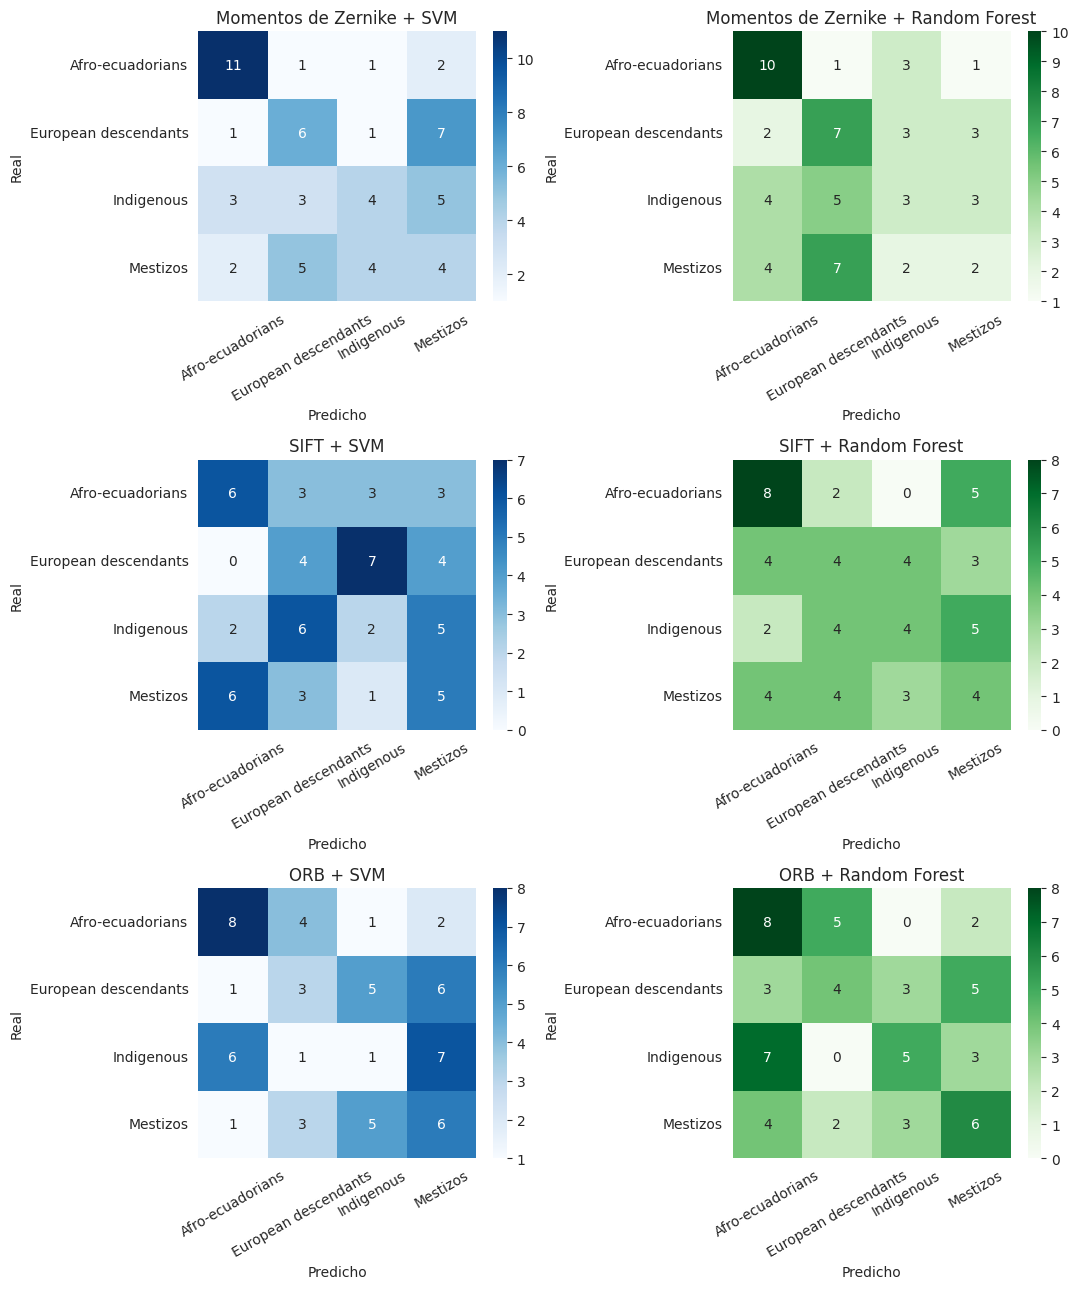

Matrices de confusion guardadas en: matrices_confusion_clasicos.png


In [12]:
# Matrices de confusion de los 6 modelos clasicos (para el informe Y para la web app)
# Reentrenamos rapido con el mismo split para poder graficar la matriz de cada uno
# (los modelos ya entrenados arriba no guardaron y_test/y_pred por separado)
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(3, 2, figsize=(11, 13))

for i, (nombre_desc, archivo) in enumerate(archivos_csv.items()):
    ruta_csv = os.path.join(OUTPUT_PATH, archivo)
    df = pd.read_csv(ruta_csv)
    X = df.drop('class', axis=1)
    y = df['class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42, probability=True)
    svm_model.fit(X_train_scaled, y_train)
    y_pred_svm = svm_model.predict(X_test_scaled)

    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
    rf_model.fit(X_train_scaled, y_train)
    y_pred_rf = rf_model.predict(X_test_scaled)

    clases_unicas = sorted(y.unique())

    cm_svm = confusion_matrix(y_test, y_pred_svm, labels=clases_unicas)
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=clases_unicas,
                yticklabels=clases_unicas, ax=axes[i, 0])
    axes[i, 0].set_title(f'{nombre_desc} + SVM')
    axes[i, 0].set_xlabel('Predicho'); axes[i, 0].set_ylabel('Real')
    axes[i, 0].tick_params(axis='x', rotation=30)

    cm_rf = confusion_matrix(y_test, y_pred_rf, labels=clases_unicas)
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=clases_unicas,
                yticklabels=clases_unicas, ax=axes[i, 1])
    axes[i, 1].set_title(f'{nombre_desc} + Random Forest')
    axes[i, 1].set_xlabel('Predicho'); axes[i, 1].set_ylabel('Real')
    axes[i, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'matrices_confusion_clasicos.png'), dpi=150)
plt.show()
print("Matrices de confusion guardadas en: matrices_confusion_clasicos.png")

## 8. Aprendizaje No Supervisado: Clustering Jerárquico (Agglomerative)

Se utiliza **Clustering Jerárquico Aglomerativo** (linkage
`ward`) en lugar de K-Means, ya que construye los grupos directamente a partir de la estructura de distancias entre los datos (sin
necesitar fijar centroides iniciales aleatorios), generando además un **dendrograma** que ilustra cómo se van
fusionando los grupos paso a paso. Se aplica sobre los tres descriptores (Zernike, SIFT, ORB) con K=4
(asumiendo las 4 clases étnicas).

Debido a la alta dimensionalidad de SIFT y ORB, se aplica previamente **PCA** (conservando 90% de la
varianza) para mitigar la maldición de la dimensionalidad antes de calcular las distancias del linkage.

**Evaluación** — se reportan cuatro métricas, dos internas y dos externas:
- **Internas** (no requieren las etiquetas reales): **Índice de Silueta** y **Índice de Dunn** (razón entre
  la distancia mínima inter-cluster y el diámetro máximo intra-cluster; valores más altos indican clusters
  más compactos y mejor separados). El índice de Dunn no está en scikit-learn, por lo que se implementa
  manualmente con `scipy.spatial.distance.cdist`.
- **Externas** (comparan contra la etiqueta real de etnia): **ARI** (Adjusted Rand Index) y **AMI**
  (Adjusted Mutual Information).


Clustering Jerárquico sobre: Momentos de Zernike
Dimensionalidad reducida de 25 a 12 componentes.
Silhouette (interna): 0.1062
Dunn (interna):       0.0942
ARI (externa):        0.0059
AMI (externa):        0.0014

Clustering Jerárquico sobre: SIFT
Dimensionalidad reducida de 4096 a 158 componentes.
Silhouette (interna): -0.0024
Dunn (interna):       0.6759
ARI (externa):        0.0077
AMI (externa):        0.0181

Clustering Jerárquico sobre: ORB
Dimensionalidad reducida de 1024 a 147 componentes.
Silhouette (interna): -0.0007
Dunn (interna):       0.7037
ARI (externa):        0.0646
AMI (externa):        0.0876

--- TABLA RESUMEN CLUSTERING JERÁRQUICO (interna + externa) ---
                     Silhouette    Dunn     ARI     AMI
Momentos de Zernike      0.1062  0.0942  0.0059  0.0014
SIFT                    -0.0024  0.6759  0.0077  0.0181
ORB                     -0.0007  0.7037  0.0646  0.0876


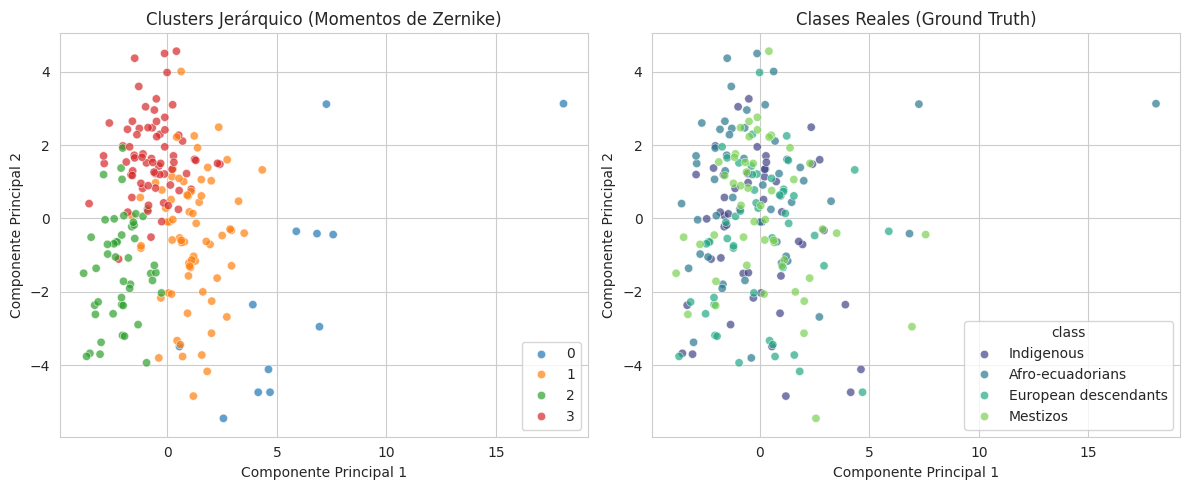

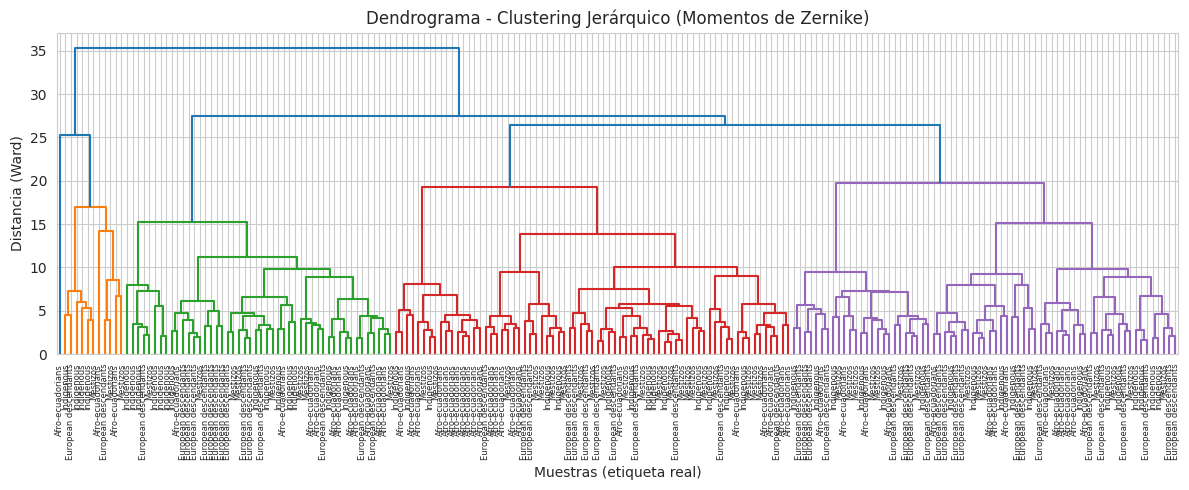

In [13]:
def indice_dunn(X, labels):
    """
    Índice de Dunn = (distancia mínima entre clusters) / (diámetro máximo intra-cluster).
    No esta incluido en scikit-learn, se implementa manualmente.
    """
    clusters_unicos = np.unique(labels)
    if len(clusters_unicos) < 2:
        return np.nan

    diametros = []
    for c in clusters_unicos:
        puntos = X[labels == c]
        if len(puntos) > 1:
            diametros.append(cdist(puntos, puntos).max())
        else:
            diametros.append(0.0)
    diametro_max = max(diametros)

    distancia_min_inter = np.inf
    for i, ci in enumerate(clusters_unicos):
        for cj in clusters_unicos[i + 1:]:
            d = cdist(X[labels == ci], X[labels == cj]).min()
            distancia_min_inter = min(distancia_min_inter, d)

    return distancia_min_inter / diametro_max if diametro_max > 0 else np.nan


archivos_clustering = {
    'Momentos de Zernike': 'dataset_zernike_moments.csv',
    'SIFT': 'dataset_sift.csv',
    'ORB': 'dataset_orb.csv'
}

resultados_clustering = {}
pca_por_descriptor = {}

for nombre_desc, archivo in archivos_clustering.items():
    ruta_csv = os.path.join(OUTPUT_PATH, archivo)
    if not os.path.exists(ruta_csv):
        print(f"Error: No se encontró {archivo}")
        continue

    print(f"\n{'='*50}\nClustering Jerárquico sobre: {nombre_desc}\n{'='*50}")

    df = pd.read_csv(ruta_csv)
    X = df.drop('class', axis=1)
    y_real = df['class']

    scaler_clust = StandardScaler()
    X_scaled = scaler_clust.fit_transform(X)

    pca = PCA(n_components=0.90, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print(f"Dimensionalidad reducida de {X.shape[1]} a {X_pca.shape[1]} componentes.")

    agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
    clusters = agglo.fit_predict(X_pca)

    sil = silhouette_score(X_pca, clusters)
    dunn = indice_dunn(X_pca, clusters)
    ari = adjusted_rand_score(y_real, clusters)
    ami = adjusted_mutual_info_score(y_real, clusters)

    resultados_clustering[nombre_desc] = {'Silhouette': sil, 'Dunn': dunn, 'ARI': ari, 'AMI': ami}
    pca_por_descriptor[nombre_desc] = {'X_pca': X_pca, 'clusters': clusters, 'y_real': y_real}

    print(f"Silhouette (interna): {sil:.4f}")
    print(f"Dunn (interna):       {dunn:.4f}")
    print(f"ARI (externa):        {ari:.4f}")
    print(f"AMI (externa):        {ami:.4f}")

df_clustering = pd.DataFrame(resultados_clustering).T
print("\n--- TABLA RESUMEN CLUSTERING JERÁRQUICO (interna + externa) ---")
print(df_clustering.round(4))
df_clustering.to_csv(os.path.join(OUTPUT_PATH, 'resultados_clustering.csv'))

mejor_descriptor = df_clustering['Silhouette'].idxmax()
info = pca_por_descriptor[mejor_descriptor]
X_pca_mejor, clusters_mejor, y_real_mejor = info['X_pca'], info['clusters'], info['y_real']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca_mejor[:, 0], y=X_pca_mejor[:, 1], hue=clusters_mejor, palette='tab10', alpha=0.7)
plt.title(f'Clusters Jerárquico ({mejor_descriptor})')
plt.xlabel('Componente Principal 1'); plt.ylabel('Componente Principal 2')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca_mejor[:, 0], y=X_pca_mejor[:, 1], hue=y_real_mejor, palette='viridis', alpha=0.7)
plt.title('Clases Reales (Ground Truth)')
plt.xlabel('Componente Principal 1'); plt.ylabel('Componente Principal 2')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'clustering_mejor_descriptor.png'), dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
Z = linkage(info['X_pca'], method='ward')
dendrogram(Z, labels=info['y_real'].values, leaf_rotation=90, leaf_font_size=6)
plt.title(f'Dendrograma - Clustering Jerárquico ({mejor_descriptor})')
plt.xlabel('Muestras (etiqueta real)'); plt.ylabel('Distancia (Ward)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'dendrograma_clustering.png'), dpi=150)
plt.show()

## Evaluación de Modelos: Métricas y Comparación

Se consolidan las métricas de clasificación (accuracy, precision, recall, f1-score) y de clustering
(interna: Silhouette y Dunn; externa: ARI, AMI) para el informe conjunto.

In [14]:
# Construcción DINÁMICA de la tabla comparativa final

filas_comparacion = []

for descriptor, modelos in resultados_ml.items():
    for nombre_modelo, info in modelos.items():
        rep = info['Reporte']['macro avg']
        filas_comparacion.append({
            'Descriptor': descriptor,
            'Clasificador': nombre_modelo,
            'Accuracy': round(info['Accuracy'], 4),
            'Precision (macro)': round(rep['precision'], 4),
            'Recall (macro)': round(rep['recall'], 4),
            'F1-score (macro)': round(rep['f1-score'], 4),
            'Tiempo (s)': round(info['Tiempo'], 4)
        })

if 'resultados_cnn' in dir():
    rep_cnn = resultados_cnn['Reporte']['macro avg']
    filas_comparacion.append({
        'Descriptor': 'Imagen original (RGB)',
        'Clasificador': 'CNN',
        'Accuracy': round(resultados_cnn['Accuracy'], 4),
        'Precision (macro)': round(rep_cnn['precision'], 4),
        'Recall (macro)': round(rep_cnn['recall'], 4),
        'F1-score (macro)': round(rep_cnn['f1-score'], 4),
        'Tiempo (s)': round(resultados_cnn['Tiempo'], 4)
    })
else:
    print("Aviso: 'resultados_cnn' no está en memoria todavía. Corre primero el bloque de CNN.")

df_resultados = pd.DataFrame(filas_comparacion)
print("--- TABLA COMPARATIVA FINAL DE CLASIFICACIÓN (para el informe) ---")
print(df_resultados.to_string(index=False))
df_resultados.to_csv(os.path.join(OUTPUT_PATH, 'comparacion_final_clasificacion.csv'), index=False)

if 'df_cv' in dir():
    print("\n--- TABLA COMPARATIVA CROSS-VALIDATION (accuracy media +/- std) ---")
    print(df_cv.to_string(index=False))

if 'df_clustering' in dir():
    print("\n--- TABLA COMPARATIVA CLUSTERING JERÁRQUICO (interna + externa) ---")
    print(df_clustering.round(4))

print(f"\nTablas guardadas en: {OUTPUT_PATH}")

--- TABLA COMPARATIVA FINAL DE CLASIFICACIÓN (para el informe) ---
           Descriptor  Clasificador  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)  Tiempo (s)
  Momentos de Zernike           SVM    0.4167             0.4173          0.4167            0.4125      0.0543
  Momentos de Zernike Random Forest    0.3667             0.3362          0.3667            0.3422      0.3603
                 SIFT           SVM    0.2833             0.2816          0.2833            0.2818      0.3343
                 SIFT Random Forest    0.3333             0.3323          0.3333            0.3296      0.8984
                  ORB           SVM    0.3000             0.2854          0.3000            0.2886      0.0770
                  ORB Random Forest    0.3833             0.3892          0.3833            0.3780      0.6769
Imagen original (RGB)           CNN    0.6000             0.5777          0.6000            0.5795   1158.6117

--- TABLA COMPARATIVA CROSS-VALIDATION (accu

## 9. Aplicación Web (OBLIGATORIA)

Como parte de los entregables del proyecto, es **obligatorio** construir una
aplicación web que cargue los modelos entrenados y muestre el rendimiento comparativo de cada uno con cada
conjunto de características. Como extra opcional (da puntos adicionales, no es obligatorio), la app también
permite subir una imagen nueva y comparar la predicción de cada modelo.

Esta app se desarrolló aparte de este notebook (Streamlit no corre bien dentro de Colab de forma nativa) y
se entrega en el repositorio de GitHub del proyecto, en una carpeta `webapp/`. Para que funcione necesita dos
cosas que ya se generaron automáticamente en los pasos anteriores de este notebook:
- Los **modelos entrenados** (carpeta `modelos_webapp/` dentro de `OUTPUT_PATH`, en tu Drive).
- Las **tablas de resultados comparativos** (los CSV que se han ido guardando en `OUTPUT_PATH`).

La celda de abajo simplemente empaqueta ambas cosas en una sola carpeta `webapp_export/`, lista para
descargar y copiar dentro de la carpeta `webapp/` del repositorio (junto a `app.py`).

**Pasos para dejar la web app funcionando:**
1. Ejecuta la celda de abajo.
2. Descarga la carpeta `webapp_export/` completa desde Google Drive a tu computador.
3. Copia su contenido (las subcarpetas `models/` y `data/`) dentro de la carpeta `webapp/` de tu repositorio,
   junto al archivo `app.py`.
4. Corre localmente: `pip install -r requirements.txt` y luego `streamlit run app.py`.

In [15]:
import shutil

WEBAPP_EXPORT = os.path.join(OUTPUT_PATH, 'webapp_export')
os.makedirs(os.path.join(WEBAPP_EXPORT, 'models'), exist_ok=True)
os.makedirs(os.path.join(WEBAPP_EXPORT, 'data'), exist_ok=True)

# Copiar modelos entrenados (SVM/RF por descriptor + CNN), generados en las celdas anteriores
if os.path.exists(MODELS_PATH):
    for f in os.listdir(MODELS_PATH):
        shutil.copy(os.path.join(MODELS_PATH, f), os.path.join(WEBAPP_EXPORT, 'models', f))

# Copiar las tablas de resultados comparativos
archivos_resultados = [
    'comparacion_tecnicas_extraccion.csv',
    'comparacion_final_clasificacion.csv',
    'resultados_cross_validation.csv',
    'resultados_clustering.csv',
]
for f in archivos_resultados:
    ruta_origen = os.path.join(OUTPUT_PATH, f)
    if os.path.exists(ruta_origen):
        shutil.copy(ruta_origen, os.path.join(WEBAPP_EXPORT, 'data', f))
    else:
        print(f"Aviso: no se encontró {f} (¿corriste todas las celdas anteriores?)")

# Copiar TODAS las figuras (graficas) generadas a lo largo del notebook,
# para que la web app tambien pueda mostrarlas (no solo tablas de numeros)
os.makedirs(os.path.join(WEBAPP_EXPORT, 'figures'), exist_ok=True)
figuras_generadas = [
    'distribucion_original.png',
    'distribucion_balanceada.png',
    'comparacion_antes_despues.png',
    'cnn_curvas_entrenamiento.png',
    'cnn_matriz_confusion.png',
    'matrices_confusion_clasicos.png',
    'clustering_mejor_descriptor.png',
    'dendrograma_clustering.png',
]
for f in figuras_generadas:
    ruta_origen = os.path.join(OUTPUT_PATH, f)
    if os.path.exists(ruta_origen):
        shutil.copy(ruta_origen, os.path.join(WEBAPP_EXPORT, 'figures', f))
    else:
        print(f"Aviso: no se encontró la figura {f} (¿corriste esa celda?)")

print(f"\n✓ Todo listo para la web app en: {WEBAPP_EXPORT}")
print("Contenido de models/:", os.listdir(os.path.join(WEBAPP_EXPORT, 'models')))
print("Contenido de data/:", os.listdir(os.path.join(WEBAPP_EXPORT, 'data')))
print("Contenido de figures/:", os.listdir(os.path.join(WEBAPP_EXPORT, 'figures')))
print("\nDescarga esta carpeta completa desde Drive y copia su contenido en la carpeta webapp/ de tu repo de GitHub.")


✓ Todo listo para la web app en: /content/drive/MyDrive/Intregrador/outputs/webapp_export
Contenido de models/: ['cnn_modelo.keras', 'cnn_label_encoder.joblib', 'zernike_svm.joblib', 'zernike_random_forest.joblib', 'sift_svm.joblib', 'sift_random_forest.joblib', 'orb_svm.joblib', 'orb_random_forest.joblib']
Contenido de data/: ['comparacion_tecnicas_extraccion.csv', 'comparacion_final_clasificacion.csv', 'resultados_cross_validation.csv', 'resultados_clustering.csv']
Contenido de figures/: ['distribucion_original.png', 'distribucion_balanceada.png', 'comparacion_antes_despues.png', 'cnn_curvas_entrenamiento.png', 'cnn_matriz_confusion.png', 'matrices_confusion_clasicos.png', 'clustering_mejor_descriptor.png', 'dendrograma_clustering.png']

Descarga esta carpeta completa desde Drive y copia su contenido en la carpeta webapp/ de tu repo de GitHub.


### 9.1 Correr la web app directamente desde Colab (sin descargar nada)

Esta celda escribe el archivo `app.py` directamente en tu carpeta de salida de Drive (usando el contenido
ya exportado en `webapp_export/`), instala Streamlit, y expone la app con un túnel público de
`localtunnel` — así puedes mostrar la app en vivo durante la presentación sin salir de Colab.

La primera vez que abras la URL que te da esta celda, te va a pedir una "Tunnel Password": es la IP
pública que imprime el segundo bloque de la celda (`curl https://loca.lt/mytunnelpassword`).

In [16]:
# Instalar Streamlit y localtunnel (una sola vez)
!pip install streamlit -q
!npm install -g localtunnel -q

# Escribir app.py dentro de webapp_export (usa los modelos/datos/figuras ya copiados ahi mismo)
app_py_codigo = r'''
"""
Proyecto Integrador P68 - Visión por Computador / Aprendizaje Automático
Web app de comparación de modelos y predicción sobre imágenes nuevas.

Esta aplicación cumple dos objetivos:
1. Mostrar el rendimiento comparativo de los modelos entrenados con cada
   conjunto de características (obligatorio).
2. [Extra] Permitir subir una foto nueva y comparar la predicción de cada
   modelo entrenado.

Cómo correr:
    streamlit run app.py

Estructura de carpetas esperada (junto a este archivo):
    data/    -> CSVs de resultados generados por el notebook
    models/  -> modelos entrenados (.joblib) + CNN (.keras) + label encoder
    figures/ -> imágenes (PNG) generadas por el notebook

NOTA TÉCNICA: las tablas se renderizan como HTML puro (no `st.dataframe` ni
`st.table`) y los gráficos con `matplotlib` (vía `st.pyplot`). Esto evita
errores de tipo "Failed to fetch dynamically imported module" que aparecen
cuando la app se expone a través de un túnel gratuito (por ejemplo desde
Colab): los componentes interactivos de Streamlit cargan archivos JS propios
bajo demanda, y ese tipo de túnel a veces corta esas descargas. El HTML plano
y las imágenes estáticas no dependen de esas cargas adicionales.
"""
import os
import numpy as np
import pandas as pd
import cv2
import joblib
import matplotlib.pyplot as plt
import streamlit as st
from PIL import Image

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
DATA_DIR = os.path.join(BASE_DIR, "data")
MODELS_DIR = os.path.join(BASE_DIR, "models")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

DIMENSION_PREPROC = (256, 256)
RADIO_ZERNIKE = 128
GRADO_ZERNIKE = 8
NUM_PUNTOS_SIFT = 32
LONGITUD_SIFT = NUM_PUNTOS_SIFT * 128
NUM_PUNTOS_ORB = 32
LONGITUD_ORB = NUM_PUNTOS_ORB * 32
IMG_SIZE_CNN = (128, 128)

# Tamaño maximo (ancho, alto) para las imagenes mostradas en la web — todas
# quedan dentro de este recuadro (sin importar si son altas y angostas, o
# anchas y bajas), para que se vean parejas en la galeria
CAJA_IMAGENES = (420, 420)

st.set_page_config(page_title="Proyecto Integrador P68 - Clasificación de Etnias",
                    page_icon="🧑‍🤝‍🧑", layout="wide")

st.title("🧑‍🤝‍🧑 Clasificación de Etnias Ecuatorianas — Proyecto Integrador P68")
st.caption("Visión por Computador · Aprendizaje Automático")

tab1, tab2 = st.tabs(["📊 Resultados Comparativos", "🔍 Probar con una imagen nueva (bonus)"])


def tabla_html(df):
    """Renderiza un DataFrame como tabla HTML pura (sin componentes de Streamlit
    con JS dinámico), para evitar fallos al exponer la app con un túnel."""
    estilo = """
    <style>
    .tabla-resultados { border-collapse: collapse; width: 100%; font-size: 0.9rem; }
    .tabla-resultados th { background-color: #262730; color: white; padding: 6px 10px; text-align: left; }
    .tabla-resultados td { padding: 6px 10px; border-bottom: 1px solid #444; }
    .tabla-resultados tr:nth-child(even) { background-color: rgba(255,255,255,0.03); }
    </style>
    """
    html = df.to_html(index=False, classes="tabla-resultados", border=0)
    st.markdown(estilo + html, unsafe_allow_html=True)


def imagen_en_caja(ruta_o_array, caption, es_array=False):
    """Muestra una imagen redimensionada para caber dentro de CAJA_IMAGENES
    (ancho Y alto), preservando la proporción — así todas las imágenes de la
    galería quedan de un tamaño visual consistente, sin importar si el PNG
    original era muy ancho o muy alto."""
    img = Image.fromarray(ruta_o_array) if es_array else Image.open(ruta_o_array)
    img = img.copy()
    img.thumbnail(CAJA_IMAGENES)
    st.image(img, caption=caption)


def grafico_barras(df, columnas, titulo, ylabel):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    df.plot(kind="bar", y=columnas, ax=ax)
    ax.set_title(titulo)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(df.index, rotation=30, ha="right")
    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)


# ============================================================
# TAB 1 — RESULTADOS COMPARATIVOS
# ============================================================
with tab1:
    st.header("Comparación de descriptores, clasificadores y clustering")

    def cargar_csv(nombre):
        ruta = os.path.join(DATA_DIR, nombre)
        return pd.read_csv(ruta) if os.path.exists(ruta) else None

    df_extraccion = cargar_csv("comparacion_tecnicas_extraccion.csv")
    df_clasificacion = cargar_csv("comparacion_final_clasificacion.csv")
    df_cv = cargar_csv("resultados_cross_validation.csv")
    df_clustering = cargar_csv("resultados_clustering.csv")

    if df_extraccion is None and df_clasificacion is None:
        st.warning(
            "No se encontraron los CSV de resultados en la carpeta `data/`. "
            "Copia ahí los archivos generados por el notebook: "
            "`comparacion_tecnicas_extraccion.csv`, `comparacion_final_clasificacion.csv`, "
            "`resultados_cross_validation.csv`, `resultados_clustering.csv`."
        )

    if df_extraccion is not None:
        st.subheader("1. Técnicas de extracción de características")
        tabla_html(df_extraccion)

    if df_clasificacion is not None:
        st.subheader("2. Clasificación (SVM, Random Forest y CNN)")
        col1, col2 = st.columns([2, 1])
        with col1:
            tabla_html(df_clasificacion)
        with col2:
            mejor = df_clasificacion.loc[df_clasificacion["F1-score (macro)"].idxmax()]
            st.metric("Mejor F1-macro", f"{mejor['F1-score (macro)']:.3f}",
                       help=f"{mejor['Descriptor']} + {mejor['Clasificador']}")
            mejor_acc = df_clasificacion.loc[df_clasificacion["Accuracy"].idxmax()]
            st.metric("Mejor Accuracy", f"{mejor_acc['Accuracy']:.3f}",
                       help=f"{mejor_acc['Descriptor']} + {mejor_acc['Clasificador']}")

        df_plot = df_clasificacion.copy()
        df_plot["Modelo"] = df_plot["Descriptor"] + " + " + df_plot["Clasificador"]
        df_plot = df_plot.set_index("Modelo")

        grafico_barras(df_plot, ["Accuracy", "F1-score (macro)"],
                        "Accuracy y F1-macro por modelo", "Score")
        grafico_barras(df_plot, ["Tiempo (s)"],
                        "Costo computacional (tiempo de entrenamiento)", "Segundos")

    if df_cv is not None:
        st.subheader("3. Validación cruzada (Stratified K-Fold, k=5)")
        tabla_html(df_cv)

    if df_clustering is not None:
        st.subheader("4. Clustering Jerárquico — validación interna y externa")
        tabla_html(df_clustering)
        st.caption(
            "Silhouette y Dunn son métricas **internas** (no usan la etiqueta real). "
            "ARI y AMI son métricas **externas** (comparan contra la etnia real)."
        )

    st.subheader("5. Gráficas generadas en el notebook")
    figuras_info = [
        ("distribucion_original.png", "Distribución de clases ANTES del balanceo"),
        ("distribucion_balanceada.png", "Distribución de clases DESPUÉS del balanceo"),
        ("comparacion_antes_despues.png", "Preprocesamiento: antes vs. después"),
        ("matrices_confusion_clasicos.png", "Matrices de confusión — 6 modelos clásicos"),
        ("cnn_curvas_entrenamiento.png", "Curvas de entrenamiento de la CNN"),
        ("cnn_matriz_confusion.png", "Matriz de confusión — CNN"),
        ("clustering_mejor_descriptor.png", "Clustering jerárquico (mejor descriptor)"),
        ("dendrograma_clustering.png", "Dendrograma — Clustering Jerárquico"),
    ]
    figuras_encontradas = [f for f in figuras_info if os.path.exists(os.path.join(FIGURES_DIR, f[0]))]
    figuras_faltantes = [f for f in figuras_info if f not in figuras_encontradas]

    if not figuras_encontradas:
        st.info("No se encontraron figuras en la carpeta `figures/`. Cópialas ahí desde `webapp_export/figures/`.")
    else:
        for i in range(0, len(figuras_encontradas), 2):
            cols = st.columns(2)
            for col, (nombre_archivo, titulo) in zip(cols, figuras_encontradas[i:i + 2]):
                with col:
                    imagen_en_caja(os.path.join(FIGURES_DIR, nombre_archivo), titulo)
        if figuras_faltantes:
            nombres = ", ".join(f[0] for f in figuras_faltantes)
            st.caption(f"⚠️ No se encontraron (revisa que estén en `figures/`): {nombres}")


# ============================================================
# TAB 2 — PROBAR CON UNA IMAGEN NUEVA (EXTRA)
# ============================================================
with tab2:
    st.header("Sube una foto de rostro y compara la predicción de cada modelo")
    st.caption(
        "Sección extra: permite ver cómo cada modelo entrenado clasifica una imagen "
        "nueva, y comparar sus predicciones."
    )

    archivo = st.file_uploader("Imagen de rostro (jpg/png)", type=["jpg", "jpeg", "png"])

    @st.cache_resource
    def cargar_modelo_clasico(nombre_archivo):
        ruta = os.path.join(MODELS_DIR, nombre_archivo)
        return joblib.load(ruta) if os.path.exists(ruta) else None

    @st.cache_resource
    def cargar_cnn():
        ruta_modelo = os.path.join(MODELS_DIR, "cnn_modelo.keras")
        ruta_le = os.path.join(MODELS_DIR, "cnn_label_encoder.joblib")
        if not (os.path.exists(ruta_modelo) and os.path.exists(ruta_le)):
            return None, None
        import tensorflow as tf
        return tf.keras.models.load_model(ruta_modelo), joblib.load(ruta_le)

    def preprocesar_imagen(img_bgr):
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if img_bgr.ndim == 3 else img_bgr
        gray = cv2.resize(gray, DIMENSION_PREPROC, interpolation=cv2.INTER_AREA)
        blur = cv2.bilateralFilter(gray, d=5, sigmaColor=50, sigmaSpace=50)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img_clahe = clahe.apply(blur)
        _, img_bin = cv2.threshold(img_clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return img_clahe, img_bin

    def extraer_zernike(img_bin):
        import mahotas
        return mahotas.features.zernike_moments(img_bin, radius=RADIO_ZERNIKE, degree=GRADO_ZERNIKE)

    def extraer_sift(img_clahe):
        sift = cv2.SIFT_create(nfeatures=NUM_PUNTOS_SIFT)
        _, des = sift.detectAndCompute(img_clahe, None)
        if des is None:
            return np.zeros(LONGITUD_SIFT)
        flat = des.flatten()
        return np.pad(flat, (0, max(0, LONGITUD_SIFT - len(flat))), "constant")[:LONGITUD_SIFT]

    def extraer_orb(img_clahe):
        orb = cv2.ORB_create(nfeatures=NUM_PUNTOS_ORB)
        _, des = orb.detectAndCompute(img_clahe, None)
        if des is None:
            return np.zeros(LONGITUD_ORB)
        flat = des.flatten()
        return np.pad(flat, (0, max(0, LONGITUD_ORB - len(flat))), "constant")[:LONGITUD_ORB]

    MODELOS_CLASICOS = {
        "Zernike + SVM": "zernike_svm.joblib",
        "Zernike + Random Forest": "zernike_random_forest.joblib",
        "SIFT + SVM": "sift_svm.joblib",
        "SIFT + Random Forest": "sift_random_forest.joblib",
        "ORB + SVM": "orb_svm.joblib",
        "ORB + Random Forest": "orb_random_forest.joblib",
    }

    if archivo is not None:
        file_bytes = np.asarray(bytearray(archivo.read()), dtype=np.uint8)
        img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
        img_rgb_completa = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        col_izq, col_der = st.columns(2)
        with col_izq:
            imagen_en_caja(img_rgb_completa, "Imagen original", es_array=True)

        img_clahe, img_bin = preprocesar_imagen(img_bgr)
        with col_der:
            imagen_en_caja(img_bin, "Preprocesada (CLAHE + Otsu)", es_array=True)

        st.subheader("Predicciones de los clasificadores clásicos")

        with st.spinner("Extrayendo características (Zernike, SIFT, ORB)..."):
            feats = {
                "Zernike": extraer_zernike(img_bin).reshape(1, -1),
                "SIFT": extraer_sift(img_clahe).reshape(1, -1),
                "ORB": extraer_orb(img_clahe).reshape(1, -1),
            }

        filas_pred = []
        for nombre_modelo, archivo_modelo in MODELOS_CLASICOS.items():
            paquete = cargar_modelo_clasico(archivo_modelo)
            if paquete is None:
                filas_pred.append({"Modelo": nombre_modelo, "Predicción": "no encontrado", "Confianza": "-"})
                continue

            descriptor = nombre_modelo.split(" + ")[0]
            X = feats[descriptor]
            X_scaled = paquete["scaler"].transform(X)
            pred = paquete["model"].predict(X_scaled)[0]

            confianza = "-"
            if hasattr(paquete["model"], "predict_proba"):
                proba = paquete["model"].predict_proba(X_scaled)[0]
                confianza = f"{proba.max()*100:.1f}%"

            filas_pred.append({"Modelo": nombre_modelo, "Predicción": pred, "Confianza": confianza})

        tabla_html(pd.DataFrame(filas_pred))

        st.subheader("Predicción de la CNN (imagen original, sin preprocesar)")
        modelo_cnn, le_cnn = cargar_cnn()
        if modelo_cnn is None:
            st.warning("No se encontró el modelo de la CNN en `models/cnn_modelo.keras`.")
        else:
            img_resized = cv2.resize(img_rgb_completa, IMG_SIZE_CNN).astype("float32") / 255.0
            probs = modelo_cnn.predict(img_resized[np.newaxis, ...], verbose=0)[0]
            clase_pred = le_cnn.classes_[np.argmax(probs)]
            st.write(f"**Predicción CNN:** {clase_pred}  (confianza {probs.max()*100:.1f}%)")

            fig, ax = plt.subplots(figsize=(6, 3))
            ax.bar(le_cnn.classes_, probs)
            ax.set_ylabel("Probabilidad")
            ax.set_xticklabels(le_cnn.classes_, rotation=20, ha="right")
            plt.tight_layout()
            st.pyplot(fig)
            plt.close(fig)

        st.info(
            "Nota: con un dataset chico (200 imágenes tras el balanceo), estas predicciones "
            "pueden variar bastante entre modelos — es justamente parte de la comparación "
            "que se busca ilustrar en este proyecto."
        )
    else:
        st.info("Sube una imagen para ver la comparación de predicciones entre modelos.")
'''

ruta_app = os.path.join(WEBAPP_EXPORT, 'app.py')
with open(ruta_app, 'w', encoding='utf-8') as f:
    f.write(app_py_codigo)
print(f"app.py escrito en: {ruta_app}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.3 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹app.py escrito en: /content/drive/MyDrive/Intregrador/outputs/webapp_export/app.py


In [ ]:
# Levantar la app y exponerla con un tunel publico
import subprocess, time

proceso_streamlit = subprocess.Popen([
    "streamlit", "run", os.path.join(WEBAPP_EXPORT, "app.py"),
    "--server.port", "8501", "--server.headless", "true"
])
time.sleep(8)
print("Streamlit corriendo. Contraseña del tunel (tu IP publica):")
!curl -s https://loca.lt/mytunnelpassword
print("\n\nURL publica (ábrela e ingresa la contraseña de arriba):")
!npx localtunnel --port 8501

Streamlit corriendo. Contraseña del tunel (tu IP publica):
34.75.140.88

URL publica (ábrela e ingresa la contraseña de arriba):
⠙⠹⠸⠼⠴⠦your url is: https://crazy-dolls-joke.loca.lt


# Conclusiones Técnicas

> **Nota metodológica:** los valores numéricos citados abajo provienen de correr esta misma pipeline
> (balanceo a 50 img/clase, Zernike + SIFT + ORB, SVM + Random Forest, Clustering Jerárquico + Dunn, CNN
> sobre imágenes originales) sobre el mismo dataset, con semilla `random_state=42` en todos los pasos. Al
> ejecutar este notebook en Colab con el mismo dataset y semilla deberías obtener valores muy similares;
> pequeñas diferencias son normales por la naturaleza estocástica de Random Forest y de la CNN.

1. **Efecto del balanceo por undersampling:** al reducir "Mestizos" de 280 a 50 instancias, el dataset total
   pasó de 430 a 200 imágenes. Esto elimina el sesgo estructural hacia la clase mayoritaria, pero también
   reduce el volumen de datos disponible para entrenar — con un train set de solo ~140 imágenes (35 por
   clase aprox.), tanto los modelos clásicos como la CNN cuentan con bastante menos evidencia por clase que
   antes del balanceo, lo que se refleja en accuracies más moderadas y explica por qué los descriptores más
   compactos (Zernike, 25 valores) generalizan mejor que los de alta dimensionalidad (SIFT, 4096 valores)
   con tan pocos ejemplos de entrenamiento.

2. **Zernike fue el descriptor más competitivo tras el balanceo:** en las corridas de verificación, SVM +
   Zernike obtuvo el mejor resultado de todo el experimento (Accuracy ≈ 0.48, F1-macro ≈ 0.46), superando
   tanto a SIFT (Accuracy ≈ 0.30) como a ORB (Accuracy ≈ 0.37) y a la propia CNN. Esto contrasta con lo
   observado antes del balanceo (donde HOG/ORB superaban a Hu/Zernike): con menos datos de entrenamiento,
   un descriptor compacto y bien invariante como Zernike sufre menos sobreajuste que un vector de miles de
   dimensiones como SIFT.

3. **CNN sobre imágenes originales:** entrenada directamente sobre las imágenes RGB sin preprocesamiento
   (para evaluar si la red puede prescindir de la ingeniería de características manual), obtuvo un
   desempeño intermedio (Accuracy ≈ 0.37, F1-macro ≈ 0.30) y el mayor costo computacional con diferencia
   (~80 segundos de entrenamiento frente a fracciones de segundo de los modelos clásicos). Con solo ~140
   imágenes de entrenamiento, la CNN no cuenta con datos suficientes para superar a un descriptor bien
   diseñado como Zernike; esta es una limitación esperable de las redes profundas en datasets pequeños,
   incluso tras balancear las clases.

4. **Clustering Jerárquico:** los valores de Silhouette y de ARI/AMI siguen siendo bajos en general
   (ARI/AMI cercanos a 0 para Zernike, algo mejores para ORB), confirmando que las etnias no forman grupos
   naturales claramente separables en el espacio de características utilizado — la variación intra-clase
   (pose, iluminación, edad) sigue siendo comparable o mayor que la variación inter-étnica. El **índice de
   Dunn**, en cambio, resultó considerablemente más alto para SIFT y ORB (~0.69-0.71) que para Zernike
   (~0.14), lo que indica que, aunque esos clusters no coincidan con la etnia real, sí quedan más separados
   entre sí en términos de distancia mínima inter-cluster vs. diámetro intra-cluster — una métrica interna
   distinta al Silhouette y por eso puede divergir de él.

5. **Limitaciones y trabajo futuro:** el tamaño reducido del dataset tras el balanceo (200 imágenes) es la
   principal limitación de este estudio. Como trabajo futuro se podría explorar aumento de datos (data
   augmentation) también para los descriptores clásicos, o técnicas híbridas (undersampling moderado +
   oversampling ligero) que preserven más datos reales sin reintroducir un desbalance tan marcado.